# Exercise: Importance Sampling (1D Adaptive Grid)
+	Define a function named **Vegas_Simple(lower, upper, func, n_points, bins, iterations)** to compute a one-dimensional integral using the Importance Sampling method. The regions of importance are defined by the magnitude of the function.

	Hint:

	**Step 1**: Divide the integration range into a specified number of equal-width bins. (Note: For the first iteration, distribute the n_points uniformly across all bins).

	**Step 2**: For each iteration:
	*	Sample random points within each bin and calculate the bin's integral ($I_{bi}$).
	*	Update the number of points for the next iteration $\sim$ the bin's contribution to the total

	$w_{bin_i} = |\dfrac{I_{bi}}{\sum{I_{bj}}} |$.

	Ensure every bin receives at least 2 points to maintain the grid.

	**Step 3**: Return the final estimate in the form $\bar{I} \pm \sigma_{\bar{I}}$, where 
	$\bar{I}$ is the mean of all iterations and 
	$\sigma_{\bar{I}}$ is the standard error calculated as follow:
	+	For every bin $b_i$, the variance is $(\sigma_{\bar{b_i}})^2 = \dfrac{\sigma_{b_i}^2}{n_i}, n_i$ is the number of points in that bin 
	+	The variance of the total integral for a single iteration $j$: $\sigma_{\bar{I_j}}^2 = \sum_{\text{all bins}} \sigma_{\bar{b_i}}^2$
	+	The standard error after N iterations is $\sigma_{\bar{I}} = \frac{1}{N} * \sqrt{\sum\sigma_{\bar{I_j}}^2} $

+	Using your function to compute the following integral:
	$$ I = \int_{0}^{2 \pi} \sin^2(x)dx$$
+	Verify the result by calculating the absolute error: $|\bar{I} - \pi|$
<!-- +	Analyze the convergence: Change the number of points and plot the absolute error and the Standard error (std) as a function of the number of points using log-log scale. Discussion: How do these errors behave as the number of points increases? -->
+	Compare the convergence of the Vegas simple method and the uniform method (using your previous MC_1dim function) by plotting the standard error of both approaches on a log-log scale. Which method has a smaller error? Ensure both methods have the same total number of points (total points = iterations x n_points for Vegas).
+	Modify the Vegas_Simple function so that it returns the results and the total number of random points sampled in each bin across all iterations. Plot the distribution of these points after several iteration steps to observe how the sampling behavior evolves.

---
# Solution
---

# Imports

In [146]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Callable, Tuple, List

# Helpers

## Bin class implementation

In [147]:
class Bin:
    def __init__(self, lower, upper, n_points=0):
        self.lower = lower
        self.upper = upper

        self.points = []

        self.update(n_points)

    def update(self, num_points):
        if type(num_points) != int:
            num_points = int(num_points)

        num_points = max(2,num_points)

        new_points = np.random.uniform(self.lower, self.upper, size=num_points)
        self.points = new_points

    def __len__(self):
        return len(self.points)

    def __str__(self):
        return str(self.points)

    def __iter__(self):
        return iter(self.points)


## 1 Dim Monte Carlo integration method

In [148]:
def calculate_integral(bin_local, func):

    lower_bound = bin_local.lower
    upper_bound = bin_local.upper
    n_points = len(bin_local)

    bin_width = upper_bound - lower_bound

    y_values = [func(x) for x in bin_local]

    y_mean = np.mean(y_values)

    result_local = bin_width * y_mean

    variance = np.sum((y_values - y_mean) ** 2) / (n_points - 1)

    std_error_local = bin_width * np.sqrt(variance / n_points)

    return result_local, std_error_local

**Explonation:**
> Here is simple monte carlo integral, but instead of normal params you just give, bin with points and then func to calculate integral of

# Vegas-Simple

## Vegas Implementation

In [165]:
def Vegas_Simple(lower: float, upper: float, func: Callable[[np.ndarray], np.ndarray], n_points: int, bins: int, iterations: int) -> Tuple[float, float, List[List[int]]]:
    """
    Returns:
        (result, std_error, points_distribution_per_iteration)
    """
    bins_split = np.linspace(lower,upper, bins+1)

    bins_arr = []
    # step 1 - uniformy distrubuted points across the n-bins
    for start, end in zip(bins_split, bins_split[1:]):
        # bins have to have at least 2 points at start
        bins_arr.append( Bin(lower=start, upper=end, n_points=max(2,n_points//bins)) )

    # step 2 - iterations
    iter_results = 0
    iter_std_error = 0
    points_distribution_per_iter = []

    for i in range(iterations):
        iter_bins_result = []
        iter_bins_std_error = []
        iter_bins_point_distribution = []

        summed_bins_result = 0
        summed_bins_std_error = 0

        # step 2.1 - integral calculation
        for bin in bins_arr:
            result_bin, std_error_bin = calculate_integral(bin, func)

            summed_bins_result += result_bin
            summed_bins_std_error += (std_error_bin**2)

            iter_bins_std_error.append(std_error_bin)
            iter_bins_result.append(result_bin)

        # step 2.2 - bins points update
        for bin, result_bin in zip(bins_arr, iter_bins_result):
            bin_coef = np.abs(result_bin / summed_bins_result)

            iter_bins_point_distribution.append(len(bin))
            new_num_points = np.ceil(bin_coef*n_points)

            bin.update(new_num_points)


        # accumulate iteration results and std_err
        iter_results += summed_bins_result
        iter_std_error += summed_bins_std_error
        points_distribution_per_iter.append(iter_bins_point_distribution)

    # step 3 - calculate final results
    result_local = iter_results/iterations
    std_error_local = np.sqrt(iter_std_error)/iterations


    return result_local, std_error_local, points_distribution_per_iter

**Explonation**
> Here you can see implementation of adaptive grid algorithm for 1D

# Testing

## Simple run

In [150]:
def func_to_integral(x):
    return np.sin(x)**2

In [166]:
result, std_err, points_distribution = Vegas_Simple(lower=0, upper=2*np.pi, func=func_to_integral, n_points=2000, bins=20, iterations=400)

In [152]:
print(f"Comparison:\n- True: {np.pi:.4f}\n- Vegas: {result:.4f}\n- Abs Error: {np.abs(((np.pi) - result)):.4f}\n- STD error: {std_err:.4f}")

Comparison:
- True: 3.1416
- Vegas: 3.1412
- Abs Error: 0.0004
- STD error: 0.0006


**Explonation**
> So not bad, you can see that in deed we converged with our algorithms.

## Convergence comparance

In [153]:
def MC_1dim(lower_bound, upper_bound, func, n_points):
    sum = 0
    points_local = np.random.uniform(lower_bound, upper_bound, size=n_points)

    # calculating the mean
    y_mean_sum = 0
    for x in points_local:
        y = func(x)
        y_mean_sum += y

    y_mean = y_mean_sum / n_points

    # calculating the result
    for x in points_local:
        y = func(x)
        sum += y

    result_local = (upper_bound - lower_bound)/n_points * sum

    # calculating the standard deviation
    error_sum = 0
    for x in points_local:
        error_sum += (func(x) - y_mean) ** 2

    std_error_local = (1/np.sqrt(n_points)) * np.sqrt( (1/(n_points-1)) * error_sum )

    return result_local, std_error_local

In [154]:
lower_bound = 0
upper_bound = 2*np.pi

iterations = 400
base_std = []
vegas_std = []

points = []

for n_points in range(10,10000, 100):
    points.append(n_points)

    result_base , std_err_base = MC_1dim(lower_bound=lower_bound,
                                         upper_bound=upper_bound,
                                         func=func_to_integral,
                                         n_points=n_points)

    result_vegas, std_err_vegas, _ = Vegas_Simple(lower=lower_bound,
                                               upper=upper_bound,
                                               func=func_to_integral,
                                               n_points=n_points,
                                               iterations=iterations,
                                               bins=20)

    base_std.append(std_err_base)
    vegas_std.append(std_err_vegas)


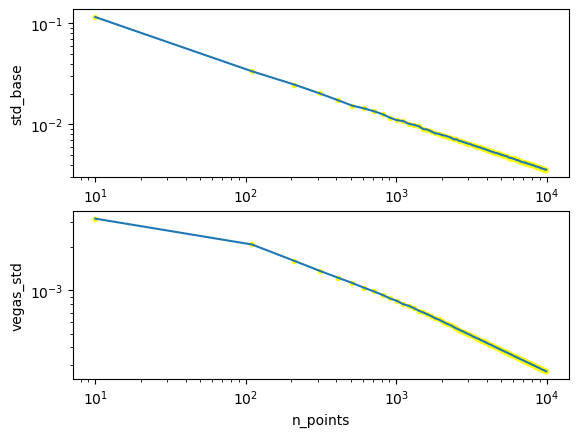

In [155]:
fig, axs = plt.subplots(2,1)

# base method
axs[0].scatter(points,base_std, marker='.', color='yellow')
axs[0].plot(points, base_std)
axs[0].set_xscale('log')
axs[0].set_yscale('log')
axs[0].set_xlabel('n_points')
axs[0].set_ylabel('std_base')

# vegas method
axs[1].scatter(points, vegas_std, marker='.', color='yellow')
axs[1].plot(points, vegas_std)
axs[1].set_xscale('log')
axs[1].set_yscale('log')
axs[1].set_xlabel('n_points')
axs[1].set_ylabel('vegas_std')

plt.show()

**Explonation**
> You can see that error with our simplified vegas algorithm is much better that standard monte calro with uniformly distrubuted points. At the end error dropped from arround $10^{-2.5}$ to $10^{-3.5}$. As expected variance dropped, which is what we wanted

## Vegas bins evolving

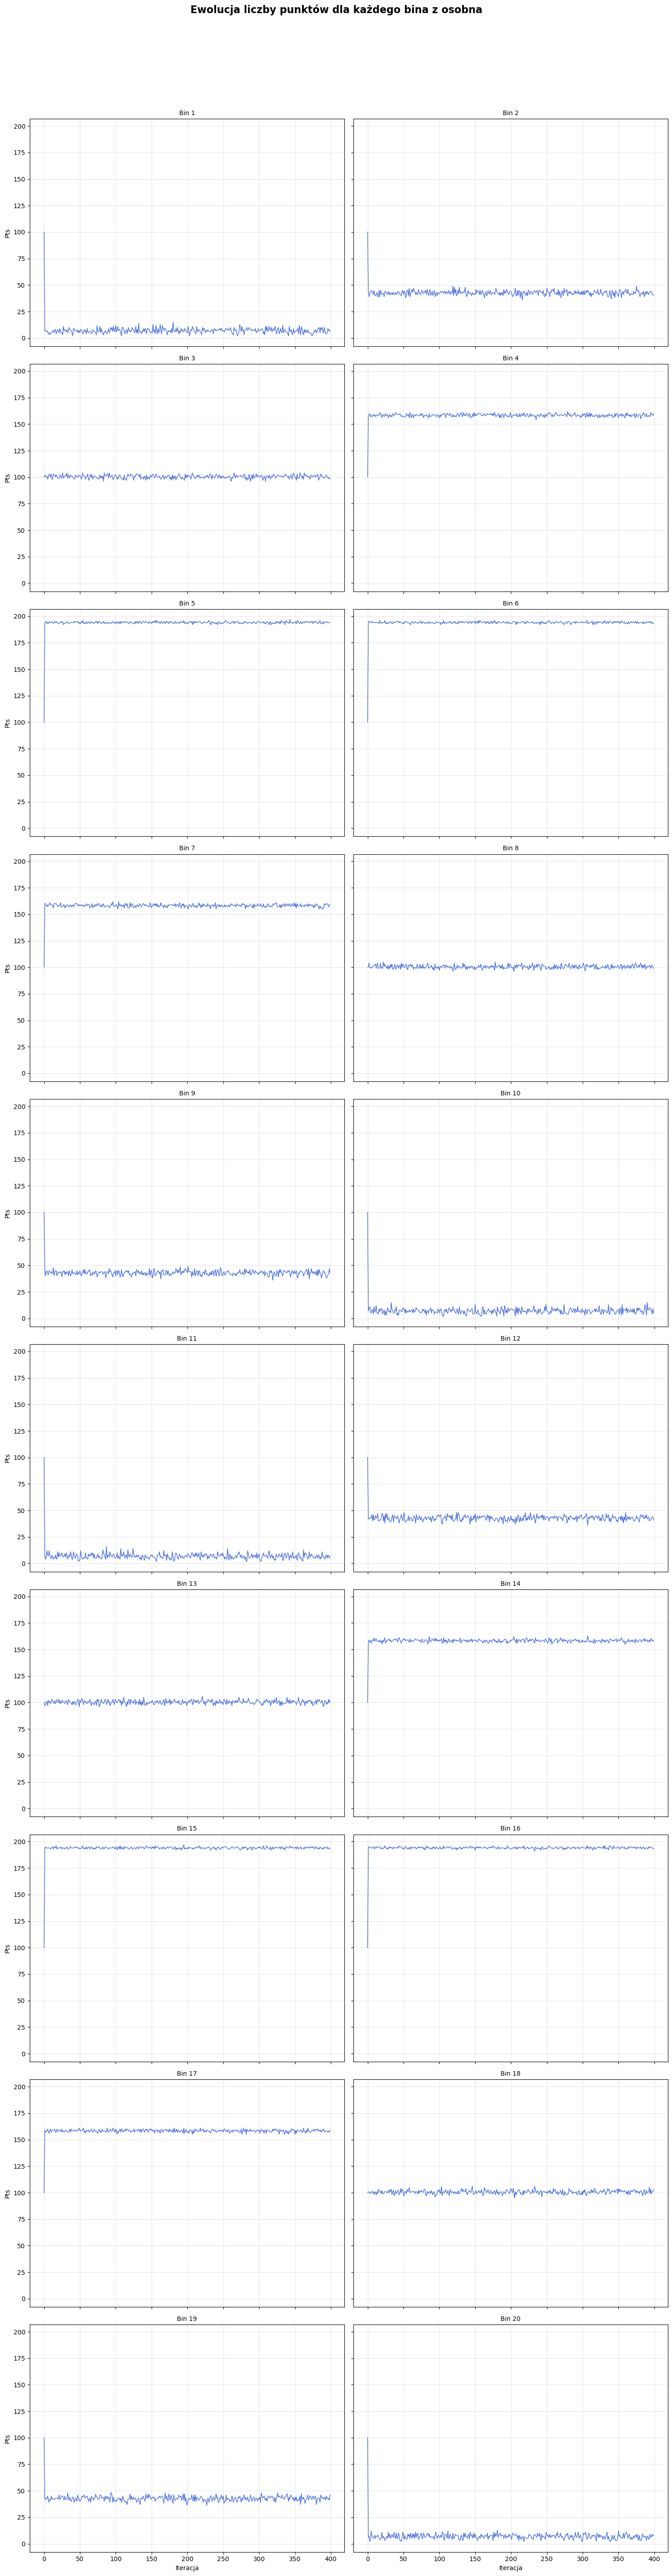

In [179]:
points = list(range(400))

distro_np = np.array(points_distribution).transpose()

# Zakładamy shape (20, 400) -> 20 binów, 400 iteracji
num_of_bins, num_of_iterations = distro_np.shape
iterations = np.arange(num_of_iterations)

# Definiujemy siatkę (np. 5 wierszy na 4 kolumny)
rows = 10
cols = 2

fig, axs = plt.subplots(rows, cols, figsize=(15, 60), sharex=True, sharey=True)
fig.suptitle('Ewolucja liczby punktów dla każdego bina z osobna', fontsize=16, fontweight='bold')

# Spłaszczamy tablicę osi, żeby łatwiej po niej iterować
axs_flat = axs.flatten()

for i in range(num_of_bins):
    ax = axs_flat[i]
    ax.plot(iterations, distro_np[i, :], color='royalblue', linewidth=1)
    ax.set_title(f'Bin {i+1}', fontsize=10)
    ax.grid(True, alpha=0.3)

    # Dodajemy etykiety tylko dla brzegowych wykresów, żeby było czyściej
    if i >= (rows - 1) * cols:
        ax.set_xlabel('Iteracja')
    if i % cols == 0:
        ax.set_ylabel('Pts')

# Usuwamy puste osie, gdyby liczba binów nie była wielokrotnością rows*cols
for j in range(num_of_bins, len(axs_flat)):
    fig.delaxes(axs_flat[j])

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Miejsce na tytuł główny
plt.show()

**Explonation:**
> Here we can see, that algorithm "points per bin" fastly converge, and it take around 1-2 iteration in order to stabilize. Of course we are doing easy function, so if we would take something harder it would need much more time to get stable... (also maybe the learning rate parameter would help to reduce big jumps in points changes...)